
**XAI study case on why customers churn 'Telco' company**

The goal of this project is to understand why customers abandon, not just to predict it.

In our study case,we are going to analyze why a customer choose to churn 'Telco' company,based on the public dataset we found online;using XAI predictions we are going to understand how to reduce the percentage of customers churning the company.

To do this, we compare a simple Logistic Regression model with a more powerful XGBoost model, and then use XAI tools to interpret the black-box behaviour so we can explain the results obtained from the black-box and give an explenation on them and why the model takes these decisions.

**Section 1 : Setup and Preprocessing**

Here we load the dataset, clean missing values and encode categorical features.

We also compute the baseline churn rate to understand the actual ratio of churning.

In [6]:
# libraries and data load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    raise FileNotFoundError("File not found. Place 'WA_Fn-UseC_-Telco-Customer-Churn.csv' in the working directory.")

# clean TotalCharges and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# prepare targets and drop useless id
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# quick stats
churn_rate = df['Churn'].mean()
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Churn rate: {churn_rate:.1%}")

# preview
df.head()


Shape: 7043 rows, 20 columns
Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Comments on the obtained results: the acutal Churn Rate (based on the actual dataset) is 26.5%.

Since 73.5% of customers stay, the data is imbalanced.

Therefore, basing only on Accuracy isn't precise.

 We will use ROC-AUC as our main metric and apply stratified splitting to maintain this class balance during training.


**Section 2 :  White Box vs Black Box performance analysis**


In this section we are training Logistic Regression and XGBoost and then we will compare their ROC-AUC.

After comparing their ROC-AUC, we will select the best performing black box model between them to use for XAI analysis.

We will also perform a check on the overfitting of the model : if the model is overfitted,a warning will appear on the output;if the model is not overfitted, the code will print 'stable model' in the output.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# 1. Data Preprocessing & Split
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. White Box Model (Logistic Regression)
model_white = LogisticRegression(max_iter=5000).fit(X_train, y_train)
auc_white = roc_auc_score(y_test, model_white.predict_proba(X_test)[:, 1])

print(f"Logistic Regression Test AUC: {auc_white:.4f}\n")

# 3. Black Box Model (XGBoost)
model_black = XGBClassifier(
    eval_metric='logloss', random_state=42,
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0
)
model_black.fit(X_train, y_train)

# 4. Evaluation & Overfitting Check
train_auc = roc_auc_score(y_train, model_black.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, model_black.predict_proba(X_test)[:, 1])
gap = train_auc - test_auc

print(f"XGBoost Train AUC: {train_auc:.4f}")
print(f"XGBoost Test AUC:  {test_auc:.4f}")
print(f"Gap: {gap:.2f}")

if gap > 0.1:
    print("Problem: High overfitting gap")
else:
    print("Stable model")

Logistic Regression Test AUC: 0.8422

XGBoost Train AUC: 0.8653
XGBoost Test AUC:  0.8475
Gap: 0.02
Stable model


Comments on the results : We have compared a simple Logistic Regression (White Box) with XGBoost (Black Box).

For the Logistic Regression we have obtained a Test AUC of 0.8422, while for the XGBoost we obtained a value of 0.8475.

The gap analysis also tells us that the model is not overfitted.

Since the XGBoost value is a bit higher than the Logistic Regression one, we select the black box model to continue with our XAI analysis.

Using this model allows us to show how XAI works to explain the decisions taken from a black box model.



**Section 3: Global and Local XAI Analysis**

In this section we will use Permutation Importance to understand which features are the most important in our project.

Then we will apply SHAP in order to understand how the model takes global decisions,local decisions (for a single customer) and to see the relation between specific features

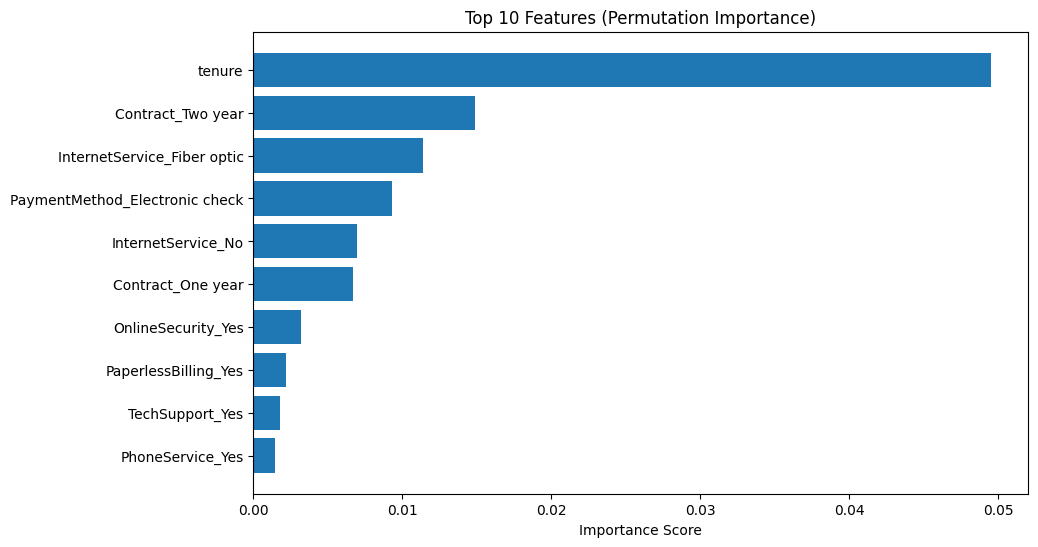

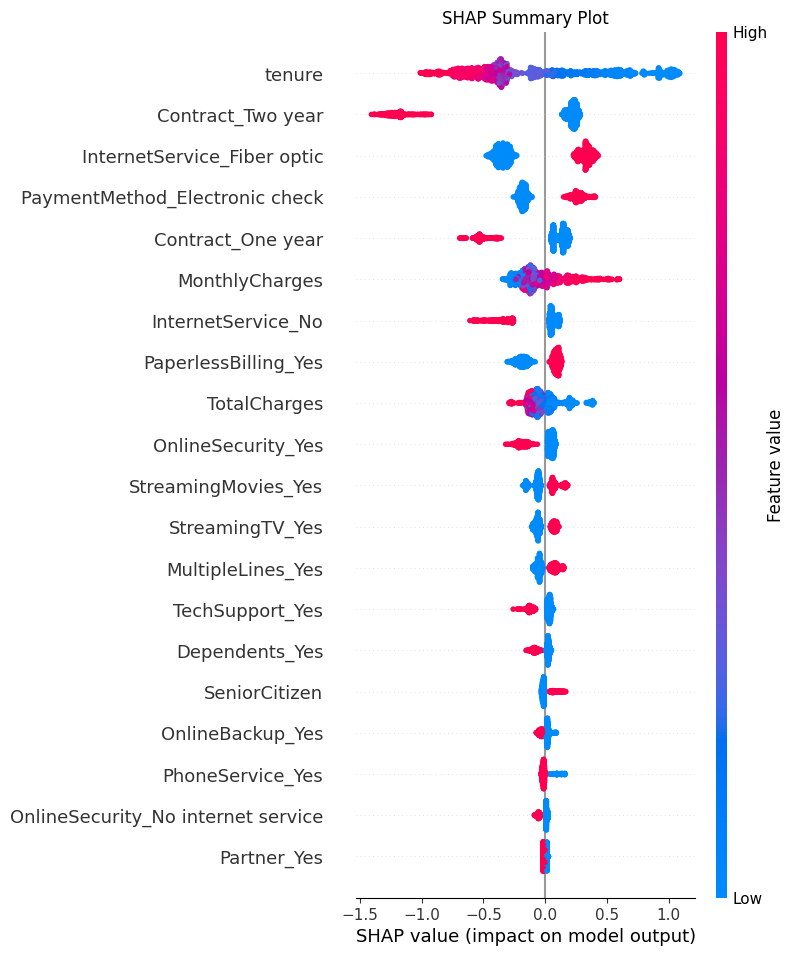

Local Explanation for High-Risk Customer #1090


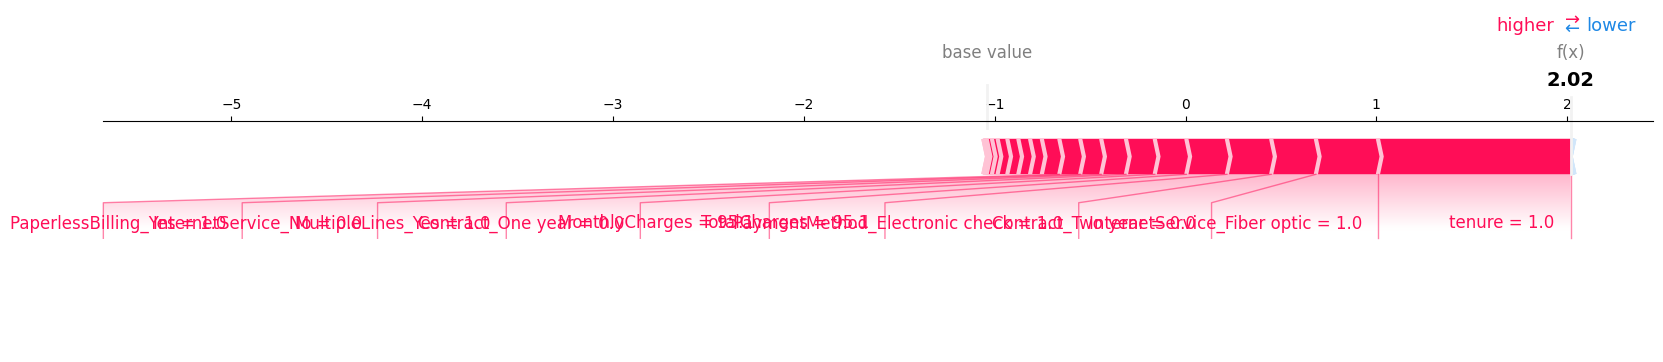

Non-Linear Feature Relationships:


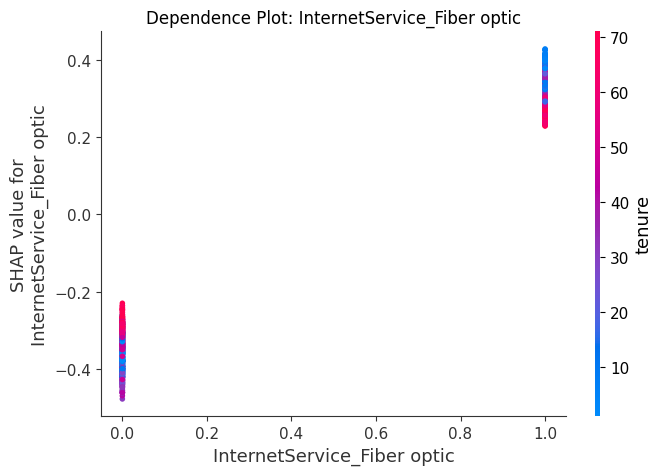

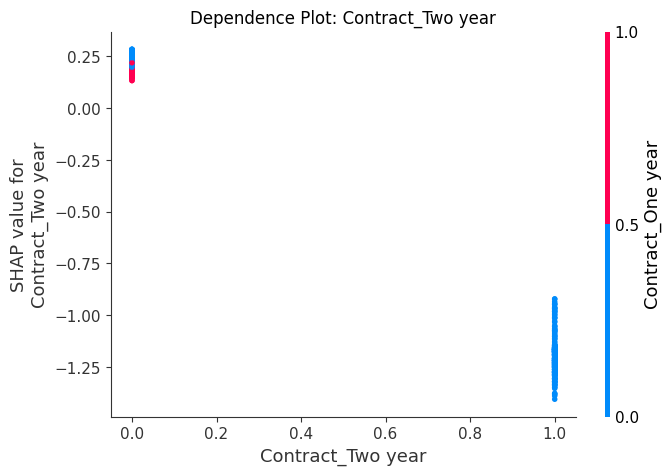

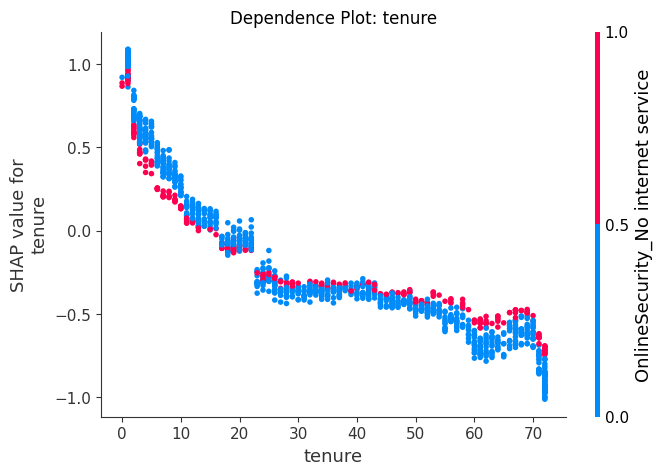

In [8]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1. Global Feature Importance (Permutation)
# This confirms which features drive most the model's performance
perm = permutation_importance(model_black, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm.importances_mean.argsort()[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], perm.importances_mean[sorted_idx])
plt.title("Top 10 Features (Permutation Importance)")
plt.xlabel("Importance Score")
plt.show()

# 2. SHAP Global Analysis
# Summary plot shows direction (churn increase/decrease) and magnitude
explainer = shap.TreeExplainer(model_black)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.show()

# 3. SHAP Local Explanation
# Deep dive into the single customer with the highest churn risk
risk_idx = np.argmax(model_black.predict_proba(X_test)[:, 1])
print(f"Local Explanation for High-Risk Customer #{risk_idx}")

shap.force_plot(
    explainer.expected_value, shap_values[risk_idx, :], X_test.iloc[risk_idx, :],
    matplotlib=True, show=False
)
plt.show()

# 4. Non-Linear Relationships (Dependence Plots)
# Visualize how the top 3 features interact with churn risk
print("Non-Linear Feature Relationships:")
for feature in X.columns[sorted_idx][-3:]:
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.title(f"Dependence Plot: {feature}")
    plt.show()

Comments on the results: looking at the results, the Permutation Importance graph  shows that Tenure (how long a customer has been with the company) is the most important factor, followed by Contract type and Internet Service.

The SHAP plot shows us how the model takes decisions.
Tenure is the most important factor: the blue dots (representing new customers) are on the right part of the graph, which means they have a very high risk of leaving. The two-year contract is also important: having this contract (red dots) pushes the risk to the left, acting as a strong protection against churn. Last, Fiber Optic internet tends to increase the risk, pushing customers towards the right side of the graph.

we also analyzed a specific high-risk customer (#1090). The Force Plot shows that for this person, the "Month-to-month" contract and Fiber Optic are the features pushing the churn risk close to 99%.

Last, the Dependence Plots shows that churn risk reduces  after some months, confirming that the relationship is not linear

**Section 4 : Understanding how changes in the proposal affect the churn rate**

In this section we are changing the contract propose to a high-risk customer to see how and if the decision changes.

By changing some conditions in the contract,we check how their predicted churn probability changes, in order to understand what actions could actually help to keep them into the company.

High-risk customers: 285
Customers retained: 277
Success rate: 97.2%


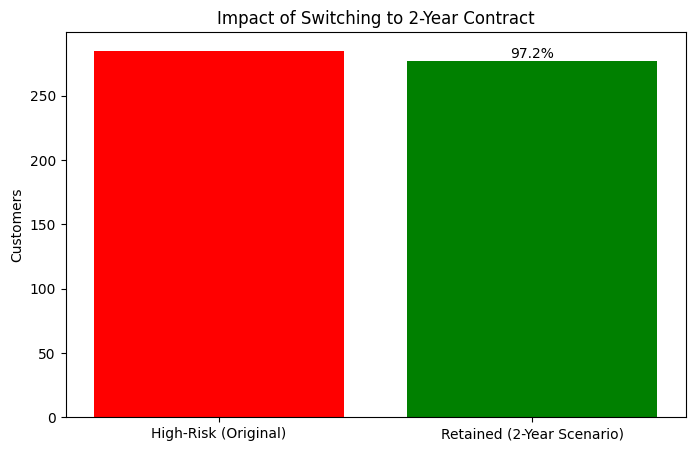

In [9]:
# select high-risk customers
risky_clients = X_test[model_black.predict(X_test) == 1].copy()

# create what-if scenario (switch to 2-year contract)
scenario_two_year = risky_clients.copy()

if 'Contract_Two year' in X.columns:
    scenario_two_year['Contract_Two year'] = 1
if 'Contract_One year' in X.columns:
    scenario_two_year['Contract_One year'] = 0

# model predictions after change
new_probs = model_black.predict_proba(scenario_two_year)[:, 1]

# count "saved" customers
saved_mask = new_probs < 0.5
num_saved = saved_mask.sum()
percent_saved = (num_saved / len(risky_clients)) * 100

print(f"High-risk customers: {len(risky_clients)}")
print(f"Customers retained: {num_saved}")
print(f"Success rate: {percent_saved:.1f}%")

# plot result
plt.figure(figsize=(8, 5))
plt.bar(
    ['High-Risk (Original)', 'Retained (2-Year Scenario)'],
    [len(risky_clients), num_saved],
    color=['red', 'green']
)
plt.title("Impact of Switching to 2-Year Contract")
plt.ylabel("Customers")
plt.text(1, num_saved, f"{percent_saved:.1f}%", ha='center', va='bottom')
plt.show()

Comments on the results: The results of the test were extremely successful.

 We started with 285 customers who the model predicted to churn the company, and after switching their contracts to a two-year plan, the model predicted we saved 277 of them.

 This gives us a 97.2% success rate;the figures prove that proposing longer-term contracts (in this case 2 years) is the best the company should use to keep a customer into the company

**Section 5: Test on the model stability**

To test if the model is stable,we will retrain the model with a different 'random seed' and see if the feature importances remain the same.

If the main features remian the same, we can trust our model.

Stability Result: Top 5/5 features match.




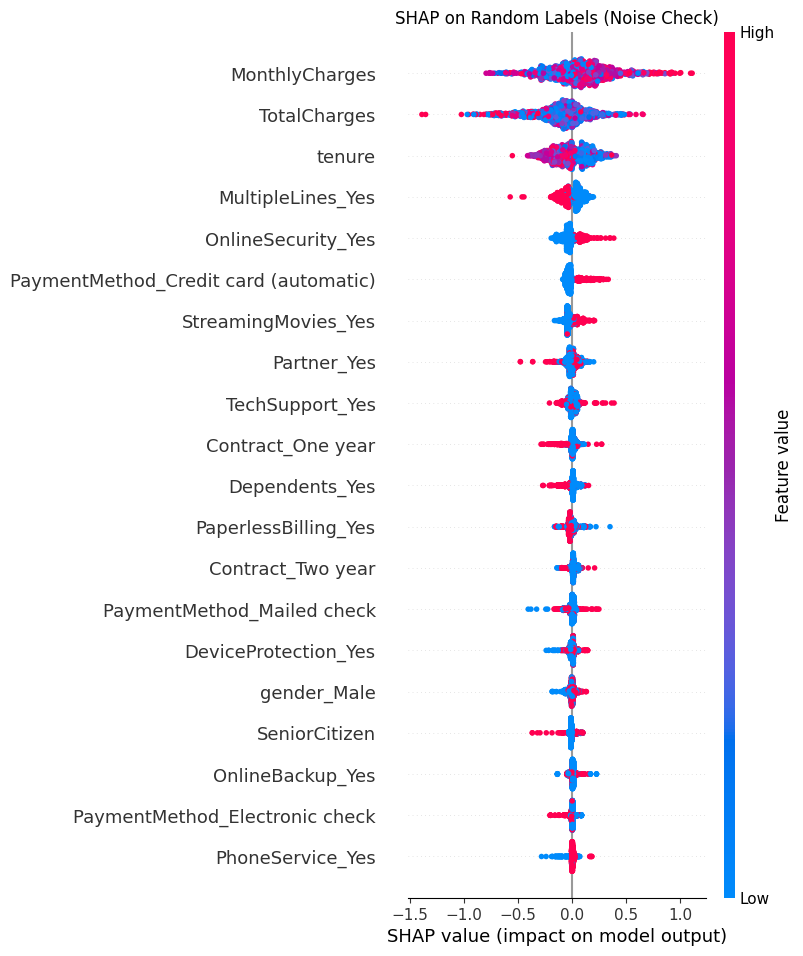

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

# 1. Stability Check
# Retrain with a new random seed to test robustness
model_check = XGBClassifier(
    eval_metric='logloss', random_state=123,
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0
)
model_check.fit(X_train, y_train)

# Compare Top 5 features
imp_orig = pd.Series(model_black.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
imp_check = pd.Series(model_check.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)

match_score = len(set(imp_orig.index).intersection(imp_check.index))
print(f"Stability Result: Top {match_score}/5 features match.\n\n")

# 2. Reliability Check
# Train on randomized labels
y_random = np.random.permutation(y_train)

model_random = XGBClassifier(eval_metric='logloss', random_state=42, n_estimators=100, max_depth=3)
model_random.fit(X_train, y_random)

# Plot SHAP
explainer_rand = shap.TreeExplainer(model_random)
shap_values_rand = explainer_rand.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values_rand, X_test, show=False)
plt.title("SHAP on Random Labels (Noise Check)")
plt.show()

Comments on the results : through this project we successfully used XAI to identify the reasons why customers churn the company;so we are able to take decisions that will help keeping customers into the company.

The model showed us that the main features are Tenure,contracts and internet service. The "What-If" simulation showed us that the best strategy is to offer longer contracts, as this action is predicted to save over 97% of our high-risk customers.

The analysis confirms that the model's explanations are reliable for taking decisions into the company,since using a new 'random seed' we obtained a 5/5 corrispondence on the main features.